# Structure-Only Marker-Removal Benchmark

Train the same model families/depths as `permutations_tests.ipynb`, but replace all marker columns with one constant node feature for both training and validation. Original marker positions are retained only for marker-wise evaluation groups.


In [24]:
import copy
import inspect
import json
import math
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [25]:
# Data and target settings
DATASET_NAME = "mean_curvature_smooth"
TARGET_INDICES = [0]
USE_GLOBAL_FEATURES = True

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and structure-only settings
VAL_FRAC = 0.2
SPLIT_SEED = None
FORCED_VAL_KEYS = set()
STRUCTURE_ONLY_CONSTANT_VALUE = 1.0
STRUCTURE_ONLY_ZERO_CONSTANT_VALUE = 0.0
STRUCTURE_ONLY_MARKER_NAMES = ["constant_node_feature"]

# Model settings
MODEL_FAMILIES = ["GIN", "GIN-zero", "ring", "ring-size"]
K_MAX = 6
DEPTHS = np.arange(0, K_MAX)
BASE_HIDDEN_DIM = 4 * 64
BASE_DROPOUT = 0.1
BASE_NORM = "batch"

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 1000
PATIENCE = 50
NUM_WORKERS = 4

# Experiment output settings
EXPERIMENT_GROUP = "structure_only_test"
RESULTS_SUBDIR = "structure_only_tests"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / RESULTS_SUBDIR / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"


In [26]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def ensure_figure_dir():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    return FIGURES_DIR


def save_mpl_figure(fig, name, *, close=False):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.pdf"
    fig.savefig(path, bbox_inches="tight", transparent=True)
    print(f"Saved figure -> {path}")
    if close:
        plt.close(fig)
    return path


def save_current_mpl_figure(name, *, close=False):
    return save_mpl_figure(plt.gcf(), name, close=close)


def save_plotly_figure(fig, name, *, scale=2):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.png"
    try:
        fig.write_image(str(path), scale=scale)
        print(f"Saved Plotly figure -> {path}")
    except Exception as exc:
        print(f"Could not save Plotly figure as PNG at {path}: {exc}")
    return path


In [27]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers.")

print_graph_and_metadata_fields(graphs)


Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers.
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [ ]:
# Optional day3p5 timepoint filter
from src.data.filters import filter_graphs_by_metadata

DAY3P5_TIMEPOINT = "day3p5"

# Default: remove day3p5 graphs if present.
graphs = filter_graphs_by_metadata(
    graphs,
    key="timepoint",
    drop_values={DAY3P5_TIMEPOINT},
    missing="keep",
    inplace=False,
    print_summary=True,
)

# Alternative: keep only day3p5 graphs and filter out all other timepoints.
# Uncomment this block and comment out the default block above if needed.
# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     keep_values={DAY3P5_TIMEPOINT},
#     missing="drop",
#     inplace=False,
#     print_summary=True,
# )


In [29]:
from src.data.metadata import fill_missing_metadata_for_group
from src.data.filters import (
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


filter_graphs_by_sphericity(max_sphericity=0.92): kept 819 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                244    342    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         290    411    0.706
20251201         day4p5              196    277    0.708
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 37     98    0.378
20250929         day4p5                9     15    0.600
20250929         day4p5-more          27    121    0.223
20251201         day4p5               20     81    0.247
filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 712 / 819 graphs

dataset          timepoint          kept  total

In [30]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


In [31]:
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)


Split -> train: 644 | val: 161
global_dim = 4


In [32]:
def snapshot_marker_features(graphs_in):
    return [g.x.detach().cpu().clone() for g in graphs_in]


def replace_marker_features_with_constant(graphs_in, *, constant_value=1.0):
    graphs_out = [copy.deepcopy(g) for g in graphs_in]
    for g in graphs_out:
        n_nodes = int(g.x.shape[0])
        g.x = torch.full(
            (n_nodes, 1),
            float(constant_value),
            dtype=g.x.dtype,
            device=g.x.device,
        )
    return graphs_out


reference_marker_x_train = snapshot_marker_features(g_train)
reference_marker_x_val = snapshot_marker_features(g_val)
reference_marker_names = list(marker_names)

g_train = replace_marker_features_with_constant(
    g_train,
    constant_value=STRUCTURE_ONLY_CONSTANT_VALUE,
)
g_val = replace_marker_features_with_constant(
    g_val,
    constant_value=STRUCTURE_ONLY_CONSTANT_VALUE,
)

g_train_zero = replace_marker_features_with_constant(
    g_train,
    constant_value=STRUCTURE_ONLY_ZERO_CONSTANT_VALUE,
)
g_val_zero = replace_marker_features_with_constant(
    g_val,
    constant_value=STRUCTURE_ONLY_ZERO_CONSTANT_VALUE,
)

print(f"Replaced marker features with {len(STRUCTURE_ONLY_MARKER_NAMES)} constant node feature.")
print("Original markers retained for evaluation groups:", reference_marker_names)
print("Training x shape:", tuple(g_train[0].x.shape))
print("Validation x shape:", tuple(g_val[0].x.shape))
print("Zero-feature training x unique values:", torch.unique(g_train_zero[0].x).detach().cpu().numpy())


Replaced marker features with 1 constant node feature.
Original markers retained for evaluation groups: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Training x shape: (265, 1)
Validation x shape: (287, 1)
Zero-feature training x unique values: [0.]


In [33]:
print("target_transform =", target_transform.name)
print("model input marker names =", STRUCTURE_ONLY_MARKER_NAMES)
print("evaluation marker names =", reference_marker_names)


target_transform = asinh_standardize
model input marker names = ['constant_node_feature']
evaluation marker names = ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']


In [34]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")


In [35]:
from src.data.ring_features import attach_precomputed_ring_features

g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)


In [36]:
from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP, PooledKHopMLP, RingSizeMLP
from src.models.io import save_model_checkpoint
from src.data.metadata import infer_global_dim

depths = DEPTHS
base_hidden_dim = BASE_HIDDEN_DIM
base_dropout = BASE_DROPOUT
base_norm = BASE_NORM

trained_model_families = {family: [] for family in MODEL_FAMILIES}

param_rows = []

for family in trained_model_families.keys():

    for k in depths:
        print(f"\n=== Training {family} model with depth={k} ===")

        train_graphs = g_train_zero if family == "GIN-zero" else g_train
        val_graphs = g_val_zero if family == "GIN-zero" else g_val

        n_markers = int(train_graphs[0].x.size(1))
        global_dim = infer_global_dim(train_graphs)

        if family in {"GIN", "GIN-zero"}:
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "train_eps": True,
                "global_dim": global_dim,
            }
            model = GINCurvature(**model_kwargs)


        elif family == "ring":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "feature_attr": "x_ring",
                "global_dim": global_dim,
            }
            model = RingFractionMLP(**model_kwargs)

        elif family == "ring-size":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "global_dim": global_dim,
            }
            model = RingSizeMLP(**model_kwargs)

        elif family == "ring-size (no center)":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "use_center_markers": False,
                "global_dim": global_dim,
            }
            model = RingSizeMLP(**model_kwargs)

        else:
            raise ValueError(f"Unknown family: {family}")

        model, metrics, history = train(model, train_graphs, val_graphs, cfg)
        trained_model_families[family].append(model)


=== Training GIN model with depth=0 ===
epoch 001 | train loss 0.5864 mae 0.8270 | val loss 0.5316 mae 0.7962
epoch 002 | train loss 0.5202 mae 0.7865 | val loss 0.4964 mae 0.7645
epoch 003 | train loss 0.4881 mae 0.7617 | val loss 0.4819 mae 0.7576
epoch 004 | train loss 0.4735 mae 0.7527 | val loss 0.4758 mae 0.7609
epoch 005 | train loss 0.4662 mae 0.7501 | val loss 0.4709 mae 0.7598
epoch 006 | train loss 0.4591 mae 0.7477 | val loss 0.4637 mae 0.7555
epoch 007 | train loss 0.4532 mae 0.7463 | val loss 0.4561 mae 0.7513
epoch 008 | train loss 0.4473 mae 0.7461 | val loss 0.4493 mae 0.7486
epoch 009 | train loss 0.4425 mae 0.7469 | val loss 0.4443 mae 0.7486
epoch 010 | train loss 0.4384 mae 0.7477 | val loss 0.4394 mae 0.7496
epoch 011 | train loss 0.4340 mae 0.7479 | val loss 0.4352 mae 0.7509
epoch 012 | train loss 0.4305 mae 0.7479 | val loss 0.4326 mae 0.7517
epoch 013 | train loss 0.4274 mae 0.7469 | val loss 0.4296 mae 0.7503
epoch 014 | train loss 0.4240 mae 0.7465 | val lo

In [37]:
from src.inference.predict import predict_targets
from src.analysis.marker_stats import compute_markerwise_nll, compute_markerwise_residuals, compute_nodewise_nll
from src.analysis.prediction_analysis import (
    _aggregate_subset_metrics,
    compute_global_uncertainty_correlation,
    compute_markerwise_uncertainty_correlation,
)


def _select_target_column(values, target_index=0):
    arr = np.asarray(values, dtype=np.float64)
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    return arr.reshape(-1)


def _concatenate_reference_markers(reference_x):
    arrays = []
    for x in reference_x:
        arr = x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)
        arrays.append(arr)
    return np.concatenate(arrays, axis=0).astype(np.float64)


def eval_model_per_reference_marker(
    model,
    eval_graphs,
    reference_x,
    *,
    device,
    target_transform=None,
    eps=1e-12,
    center_only=False,
    target_index=0,
):
    y, mu, log_var, _ = predict_targets(
        eval_graphs,
        model,
        device=device,
        return_log_var=True,
        center_only=center_only,
        target_transform=target_transform,
    )

    y_eval = _select_target_column(y, target_index=target_index)
    mu_eval = _select_target_column(mu, target_index=target_index)
    log_var_eval = _select_target_column(log_var, target_index=target_index)
    var = np.exp(log_var_eval)
    X_ref = _concatenate_reference_markers(reference_x)
    if X_ref.shape[0] != y_eval.shape[0]:
        raise ValueError(f"Reference marker rows {X_ref.shape[0]} do not match predictions {y_eval.shape[0]}.")

    residuals_model, residuals_base, n_pos_resid, mu_pos_resid = compute_markerwise_residuals(
        y_eval,
        mu_eval,
        X_ref,
    )
    mse_model = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_model])
    mse_base = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_base])

    sem_mse_model = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_model
    ])
    sem_mse_base = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_base
    ])

    Xb = X_ref > 0.5
    var_model = np.array([
        np.mean(var[Xb[:, m]]) if np.any(Xb[:, m]) else np.nan
        for m in range(X_ref.shape[1])
    ])
    sem_var_model = np.array([
        np.std(var[Xb[:, m]], ddof=1) / np.sqrt(np.sum(Xb[:, m])) if np.sum(Xb[:, m]) > 1 else np.nan
        for m in range(X_ref.shape[1])
    ])

    var_base = mse_base
    sem_var_base = sem_mse_base

    nll_model_list, nll_base_list, delta_mean_list, delta_var_list, n_pos_nll = compute_markerwise_nll(
        y_true=y_eval,
        mu_model=mu_eval,
        log_var_model=log_var_eval,
        X=X_ref,
        eps=eps,
    )

    nll_model = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_model_list])
    nll_base = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_base_list])
    sem_nll_model = np.array([
        np.std(v, ddof=1) / np.sqrt(v.size) if v.size > 1 else np.nan
        for v in nll_model_list
    ])
    sem_nll_base = np.array([
        np.std(v, ddof=1) / np.sqrt(v.size) if v.size > 1 else np.nan
        for v in nll_base_list
    ])

    rho_marker, pval_marker, n_pos_corr = compute_markerwise_uncertainty_correlation(
        y=y_eval,
        mu=mu_eval,
        log_var=log_var_eval,
        X=X_ref,
    )
    rho_global, pval_global = compute_global_uncertainty_correlation(
        y=y_eval,
        mu=mu_eval,
        log_var=log_var_eval,
    )

    row_pos = (X_ref > 0.5).sum(axis=1)
    aggregate = {
        "any_marker": _aggregate_subset_metrics(y_eval, mu_eval, log_var_eval, X_ref, row_pos > 0, eps=eps),
        "no_marker": _aggregate_subset_metrics(y_eval, mu_eval, log_var_eval, X_ref, row_pos == 0, eps=eps),
        "all_nodes": _aggregate_subset_metrics(y_eval, mu_eval, log_var_eval, X_ref, np.ones_like(row_pos, dtype=bool), eps=eps),
    }

    return {
        "mse_model": mse_model,
        "sem_mse_model": sem_mse_model,
        "mse_base": mse_base,
        "sem_mse_base": sem_mse_base,
        "var_model": var_model,
        "sem_var_model": sem_var_model,
        "var_base": var_base,
        "sem_var_base": sem_var_base,
        "nll_model": nll_model,
        "sem_nll_model": sem_nll_model,
        "nll_base": nll_base,
        "sem_nll_base": sem_nll_base,
        "rho_marker": rho_marker,
        "pval_marker": pval_marker,
        "n_pos_corr": n_pos_corr,
        "rho_global": rho_global,
        "pval_global": pval_global,
        "aggregate": aggregate,
    }


def evaluate_family_models(trained_models, eval_graphs_by_family, reference_x, device, target_transform):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        eval_graphs = eval_graphs_by_family.get(family, eval_graphs_by_family["default"])
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_reference_marker(
                model,
                eval_graphs,
                reference_x,
                device=device,
                target_transform=target_transform,
                center_only=False,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                vals = fam_aggregate[agg_name][metric]
                fam_aggregate_stacked[agg_name][metric] = np.asarray(vals, dtype=float)

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results


eval_graphs_by_family = {
    "default": g_val,
    "GIN-zero": g_val_zero,
}

eval_results = evaluate_family_models(
    trained_models=trained_model_families,
    eval_graphs_by_family=eval_graphs_by_family,
    reference_x=reference_marker_x_val,
    device=device,
    target_transform=target_transform,
)


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/structure_only_tests/run_20260511_113114/figures/validation_mse_markerwise_vs_depth.pdf


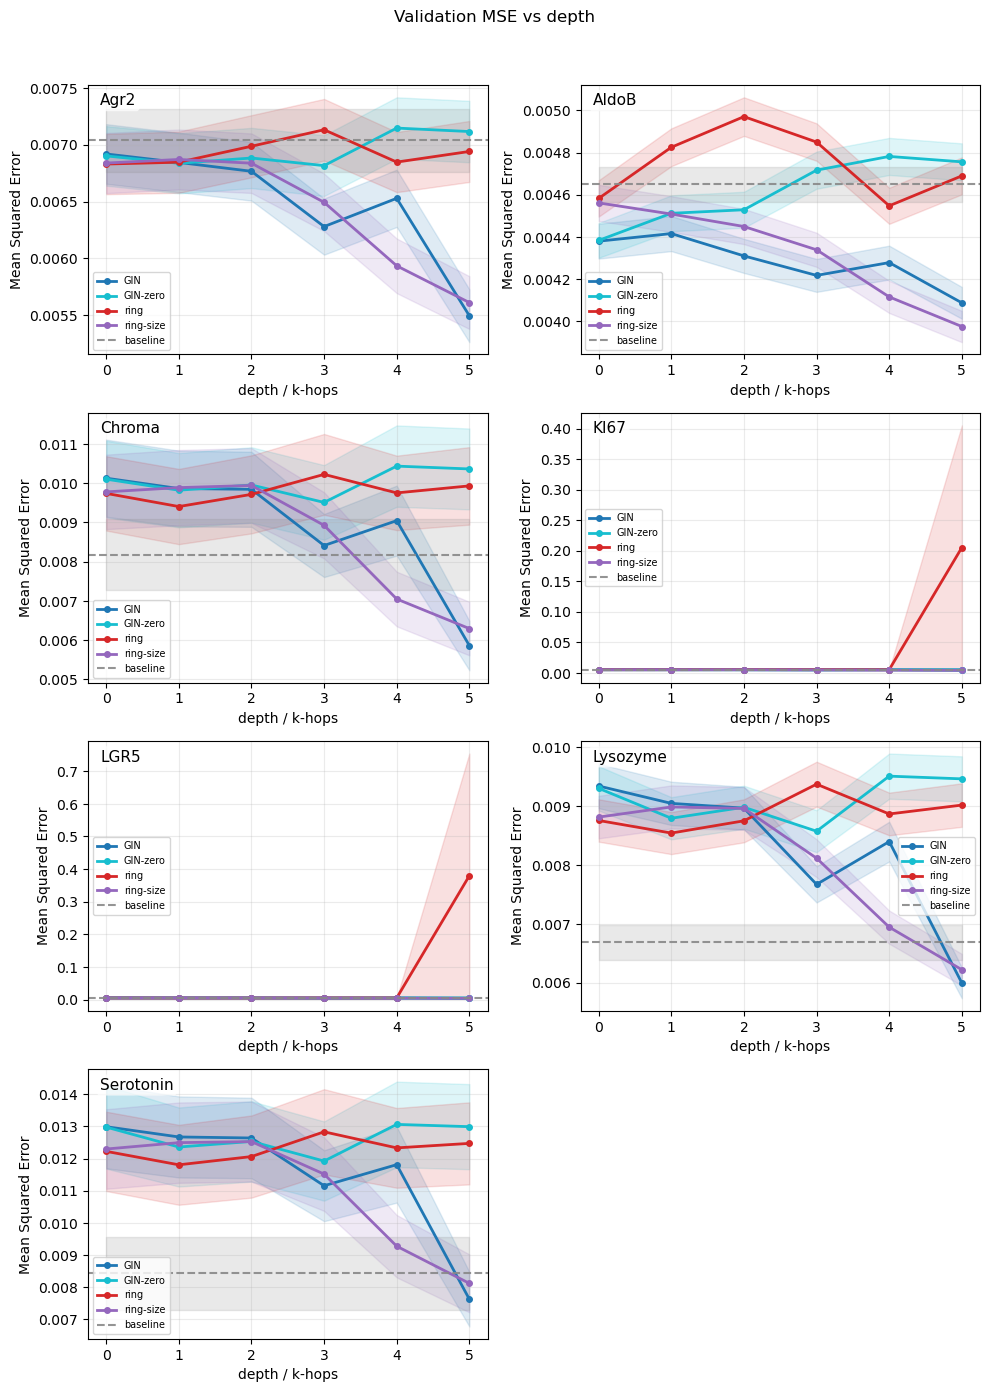

In [38]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GIN": "#1f77b4",
    "GIN-zero": "#17becf",
    # "GIN+degree": "#e377c2",
    "ring":      "#d62728",
    "ring-size": "#9467bd",
    "ring-size (no center)":       "#ff7f0e",
}


family_order = [
    "GIN",
    "GIN-zero",
    # "GIN+degree",
    "ring",
    "ring-size",
    "ring-size (no center)",
]


fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=reference_marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_mse_markerwise_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/structure_only_tests/run_20260511_113114/figures/validation_mse_all_nodes_vs_depth.pdf


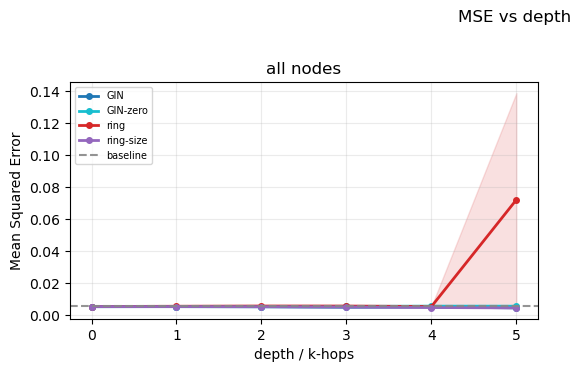

In [39]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_mse_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/structure_only_tests/run_20260511_113114/figures/validation_nll_markerwise_vs_depth.pdf


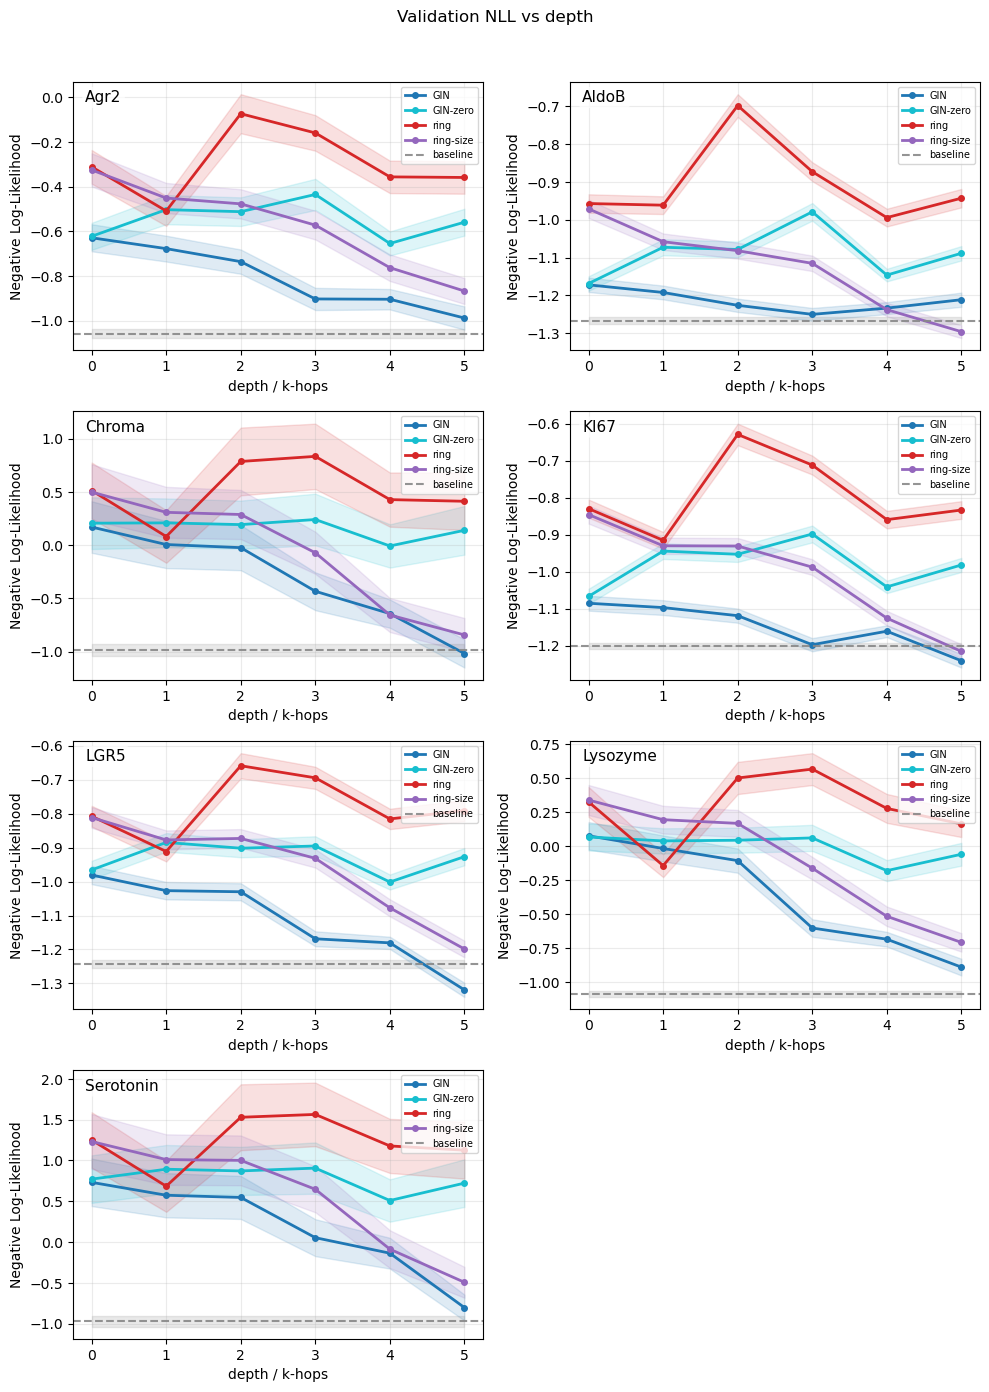

In [40]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=reference_marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_nll_markerwise_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/structure_only_tests/run_20260511_113114/figures/validation_nll_all_nodes_vs_depth.pdf


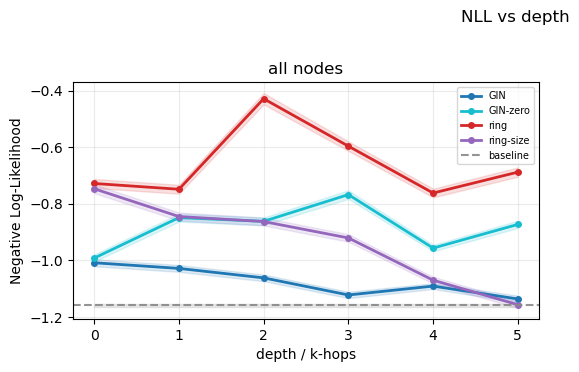

In [41]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_nll_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/structure_only_tests/run_20260511_113114/figures/uncertainty_error_correlation_markerwise_vs_depth.pdf


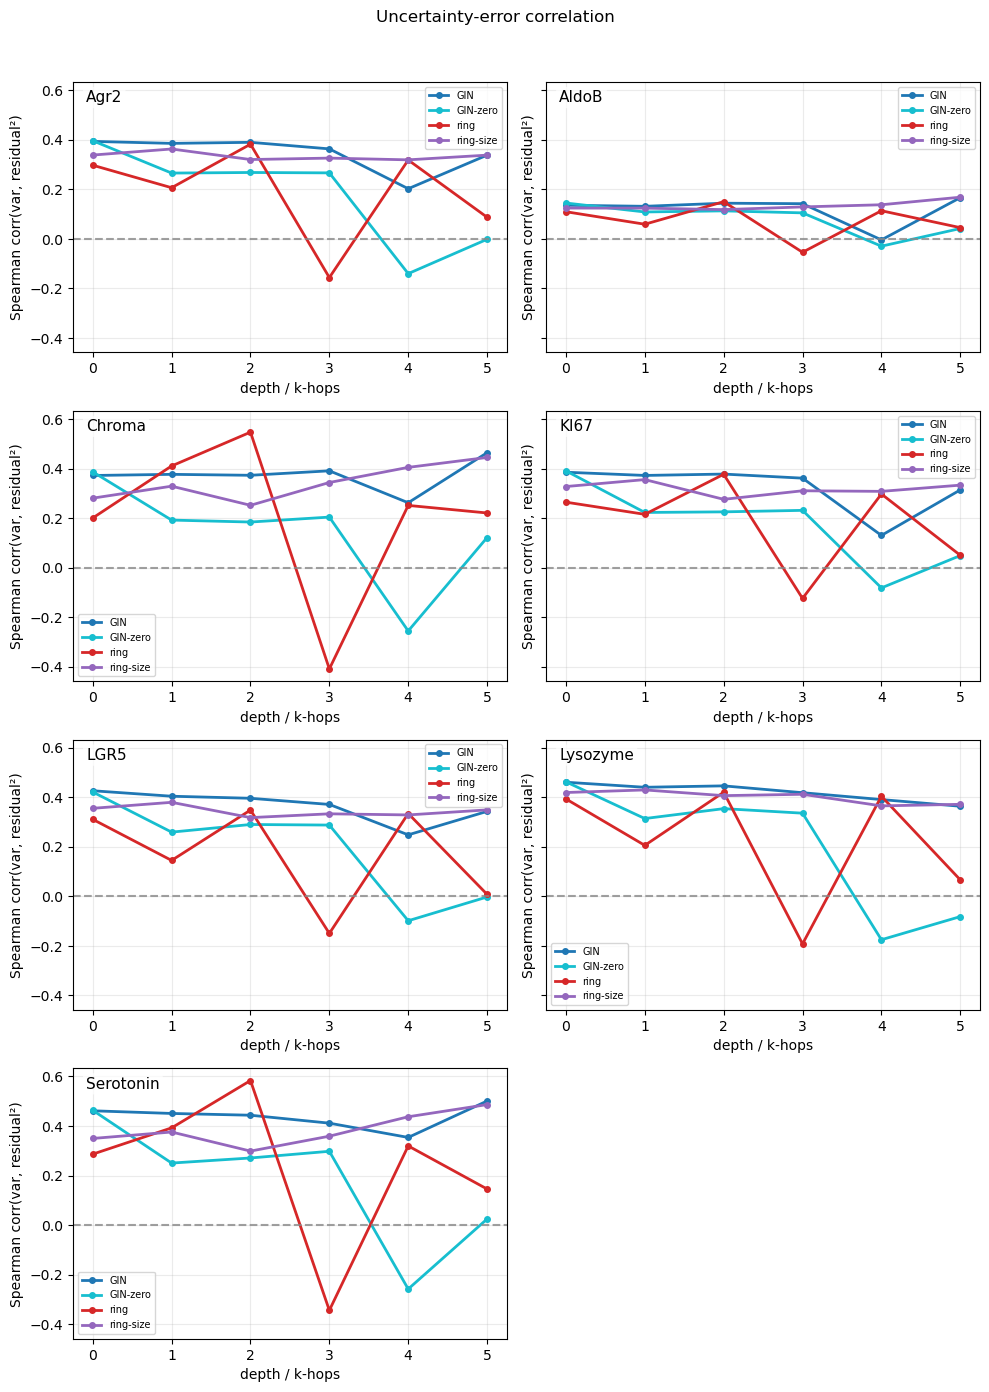

In [42]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=reference_marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
save_mpl_figure(fig, "uncertainty_error_correlation_markerwise_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/structure_only_tests/run_20260511_113114/figures/uncertainty_error_correlation_all_nodes_vs_depth.pdf


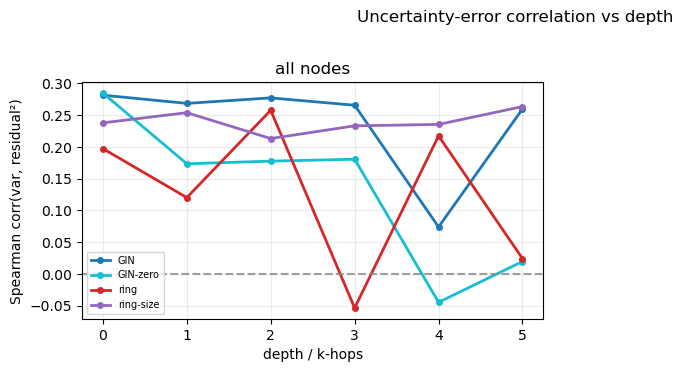

In [43]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "uncertainty_error_correlation_all_nodes_vs_depth")
plt.show()


In [44]:
def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Saved joint experiment -> {save_dir}")


In [45]:
joint_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filters": {
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
        "forced_val_keys": sorted(FORCED_VAL_KEYS),
    },
    "structure_only": {
        "constant_value": STRUCTURE_ONLY_CONSTANT_VALUE,
        "zero_constant_value": STRUCTURE_ONLY_ZERO_CONSTANT_VALUE,
        "model_input_marker_names": list(STRUCTURE_ONLY_MARKER_NAMES),
        "evaluation_marker_names": list(reference_marker_names),
    },
    "model_families": list(trained_model_families.keys()),
    "depths": depths.tolist(),
    "hidden_dim": base_hidden_dim,
    "dropout": base_dropout,
    "norm": base_norm,
    "k_max": K_MAX,
    "train_config": {
        "loss_name": cfg.loss_name,
        "lr": cfg.lr,
        "batch_size": cfg.batch_size,
        "max_epochs": cfg.max_epochs,
        "patience": cfg.patience,
        "num_workers": cfg.num_workers,
    },
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "marker_names": list(reference_marker_names),
    "figures_dir": str(FIGURES_DIR),
}


In [46]:
results_by_experiment = {
    "eval_results": eval_results,
    "param_rows": param_rows,
}

save_dir = SAVE_DIR

save_joint_experiment(
    save_dir=save_dir,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes="Compare model families when all marker signals are removed and replaced by one constant node feature; marker-wise evaluation uses saved original marker positions.",
)


Saved joint experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/structure_only_tests/run_20260511_113114
